# tarea 2 ia

clustering: el presente trabajo ejecuta en un dataset llamado "conjunto de datos de frijoles secos" al cual se le aplicaran 3 algoritmos de clustering k-means, k-means++ y meanshift con al menos 4 configuraciones por tecnica con un entrenamiento con el 80% de los datos omitiendo una etiqueta y para luego evaluar 12 configuraciones mediante silhouette score y seleccionando las 3 mejores. luego se debe aplicar cada configuracion al 20% de los datos restantes.

In [ ]:
# celda opcional para instalar dependencias desde el notebook
# importa modulos necesarios y define ruta a requerimientos.txt
# imprime informacion del interprete y archivo de requerimientos
# descomenta la linea de subprocess si necesitas instalar paquetes aqui
import sys, subprocess
from pathlib import Path
REQ = (Path.cwd().parent / 'requerimientos.txt')
print('interprete:', sys.executable)
print('requerimientos.txt:', REQ)
# subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', str(REQ)])  # descomenta si lo necesitas

Intérprete: f:\Tarea2_IA\Tarea2IAParte2\.venv\Scripts\python.exe
requerimientos.txt: f:\Tarea2_IA\Tarea2IAParte2\requerimientos.txt


In [ ]:
# detectar la raiz del proyecto y preparar rutas
# define funcion para encontrar la raiz basada en existencia de carpetas
# establece rutas para carpeta actual, raiz, y archivo de configuracion
# verifica que el archivo de configuracion exista
from pathlib import Path
def detectar_raiz(p: Path) -> Path:
    cur = p.resolve()
    while True:
        if (cur / 'configuraciones').exists() and (cur / 'aplicacion').exists():
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    return p
CWD = Path().resolve()
RAIZ = detectar_raiz(CWD)
CFG = RAIZ / 'configuraciones' / 'parte2.json'
print('carpeta actual:', CWD)
print('raiz detectada:', RAIZ)
print('config:', CFG)
assert CFG.exists(), f'no se encontro configuracion en {CFG}'

Carpeta actual: F:\Tarea2_IA\Tarea2IAParte2\cuadernos
Raíz detectada: F:\Tarea2_IA\Tarea2IAParte2
Config: F:\Tarea2_IA\Tarea2IAParte2\configuraciones\parte2.json


In [ ]:
# verificar dataset y mostrar resumen de configuracion
# carga el archivo json de configuracion y lo imprime formateado
# resuelve la ruta absoluta del dataset basado en la configuracion
# verifica que el dataset exista
import json
cfg = json.load(open(CFG, 'r', encoding='utf-8'))
print(json.dumps(cfg, ensure_ascii=False, indent=2))
from pathlib import Path
cfg_dir = CFG.parent
ruta_datos = cfg['datos']['ruta']
ds_abs = (cfg_dir / ruta_datos).resolve() if not Path(ruta_datos).is_absolute() else Path(ruta_datos)
print('dataset resuelto:', ds_abs)
assert ds_abs.exists(), f'no se encontro el dataset en {ds_abs}. corrige "datos.ruta".'

{
  "datos": {
    "ruta": "../datos/Dry_Bean_Dataset.csv",
    "etiqueta": "Class",
    "proporcion_prueba": 0.2,
    "semilla": 42,
    "escalar": true
  },
  "entrenamiento": {
    "epocas": 20,
    "eliminar_cada": 5,
    "limite_eval_entrenamiento": 40000
  },
  "busqueda": {
    "regresion_logistica": [
      {
        "nombre": "LR_opt_lote256",
        "penalizacion": "l2",
        "alpha": 0.0001,
        "ritmo_aprendizaje": "optimal",
        "tamanio_lote": 256
      },
      {
        "nombre": "LR_const1e-3_lote512",
        "penalizacion": "l2",
        "alpha": 0.0001,
        "ritmo_aprendizaje": "constant",
        "eta0": 0.001,
        "tamanio_lote": 512
      },
      {
        "nombre": "LR_inverso_lote128",
        "penalizacion": "l2",
        "alpha": 5e-05,
        "ritmo_aprendizaje": "invscaling",
        "eta0": 0.01,
        "power_t": 0.5,
        "tamanio_lote": 128
      }
    ],
    "svm": [
      {
        "nombre": "SVM_hinge_opt_lote256",
        "

## Preparacion de datos para clustering
En esta etapa se normalizan las caracteristicas numericas, se reserva la columna `class` solo como referencia y se genera la particion estratificada 80/20 que usaran los algoritmos no supervisados.

In [ ]:
# preparar matrices para clustering
# importa sys y agrega la raiz al path para importar modulos locales
# llama a la funcion preparar_datos_clustering con parametros de configuracion
# imprime estadisticas del dataset preparado
# muestra las primeras filas de los datos de entrenamiento
import sys
sys.path.append(str(RAIZ))
from aplicacion.datos import preparar_datos_clustering
_cfg_datos = cfg["datos"]
datos_clustering = preparar_datos_clustering(
    ruta_datos=str(ds_abs),
    columna_etiqueta=_cfg_datos.get("etiqueta"),
    proporcion_prueba=_cfg_datos.get("proporcion_prueba", 0.2),
    semilla=_cfg_datos.get("semilla", 42),
    escalar=_cfg_datos.get("escalar", True),
)
total_muestras, total_caracteristicas = datos_clustering["df_features"].shape
print(f"total de muestras: {total_muestras} | caracteristicas numericas: {total_caracteristicas}")
print("distribucion entrenamiento:", datos_clustering["y_entrenamiento"].value_counts().to_dict())
print("distribucion prueba:", datos_clustering["y_prueba"].value_counts().to_dict())
datos_clustering["X_entrenamiento"].head()

Total de muestras: 13611 | Características numéricas: 16
Distribución entrenamiento: {3: 2837, 6: 2109, 5: 1621, 4: 1542, 2: 1304, 0: 1057, 1: 418}
Distribución prueba: {3: 709, 6: 527, 5: 406, 4: 386, 2: 326, 0: 265, 1: 104}


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
1453,-0.371936,-0.531820,-0.695735,0.085561,-1.294404,-1.514131,-0.380542,-0.362057,0.850684,1.262235,1.517952,1.446528,-0.338282,1.119952,1.484589,0.952347
6470,0.027886,0.497114,0.781599,-0.541425,2.402044,1.491606,0.034252,0.149081,-2.945220,-0.852182,-2.378350,-1.999015,0.552393,-1.321536,-1.878274,0.155948
4639,0.725154,0.793010,0.822420,0.923721,0.076608,0.330409,0.715118,0.921581,1.196086,0.620529,0.255171,-0.200817,-1.158890,-0.787295,-0.237185,-0.357265
4655,0.730202,0.881510,1.018729,0.724522,0.614723,0.720290,0.733356,0.926755,0.863711,-0.485234,-0.253474,-0.715487,-0.967862,-1.032250,-0.732302,-0.980203
1936,-0.134375,-0.258456,-0.481832,0.493028,-1.381647,-1.711421,-0.144866,-0.050895,0.707249,1.253308,1.532152,1.569468,-0.784820,0.921082,1.621455,0.911263


In [ ]:
# particiones listas para algoritmos no supervisados
# convierte los dataframes a arrays numpy para uso en sklearn
# extrae las matrices X y Y para entrenamiento y prueba
# imprime formas y distribucion de clases
import numpy as np
X_entrenamiento = datos_clustering["X_entrenamiento"].to_numpy()
X_prueba = datos_clustering["X_prueba"].to_numpy()
y_entrenamiento = datos_clustering["y_entrenamiento"].to_numpy()
y_prueba = datos_clustering["y_prueba"].to_numpy()
mapa_etiquetas = datos_clustering["mapa_etiquetas"]
print("X_entrenamiento:", X_entrenamiento.shape)
print("X_prueba:", X_prueba.shape)
print("clases en entrenamiento:", dict(zip(*np.unique(y_entrenamiento, return_counts=True))))

X_entrenamiento: (10888, 16)
X_prueba: (2723, 16)
Clases en entrenamiento: {np.int8(0): np.int64(1057), np.int8(1): np.int64(418), np.int8(2): np.int64(1304), np.int8(3): np.int64(2837), np.int8(4): np.int64(1542), np.int8(5): np.int64(1621), np.int8(6): np.int64(2109)}


## Configuracion de algoritmos de clustering
Se proponen cuatro configuraciones por tecnica (k-means con inicializacion aleatoria, k-means++ y meanshift) justificadas segun el numero de clases y la densidad del conjunto de frijoles secos.

In [ ]:
# definir configuraciones para k-means, k-means++ y meanshift
# importa algoritmos de sklearn y estima bandwidth para meanshift
# define funcion para registrar configuraciones con justificacion
# crea listas de configuraciones para cada algoritmo con parametros variados
# imprime resumen de configuraciones
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, MeanShift, estimate_bandwidth
SEMILLA = _cfg_datos.get("semilla", 42)
muestras_bandwidth = min(5000, X_entrenamiento.shape[0])
bandwidth_base = estimate_bandwidth(
    X_entrenamiento,
    quantile=0.2,
    n_samples=muestras_bandwidth,
    random_state=SEMILLA,
 )
if not np.isfinite(bandwidth_base) or bandwidth_base <= 0:
    bandwidth_base = np.linalg.norm(np.std(X_entrenamiento, axis=0)) / np.sqrt(X_entrenamiento.shape[1])
print(f"bandwidth base estimado: {bandwidth_base:.4f}")
configuraciones_clustering = []
def _registrar(nombre, algoritmo, params, justificacion):
    cls = KMeans if "kmeans" in algoritmo else MeanShift
    configuraciones_clustering.append({
        "nombre": nombre,
        "algoritmo": algoritmo,
        "parametros": params,
        "constructor": (lambda cls=cls, params=params: cls(**params)),
        "justificacion": justificacion,
    })
for n_clust, max_iter, n_init in [(6, 500, 10), (7, 500, 15), (8, 800, 20), (10, 1000, 20)]:
    params = {
        "n_clusters": n_clust,
        "init": "random",
        "n_init": n_init,
        "max_iter": max_iter,
        "random_state": SEMILLA,
    }
    justificacion = (
        f"explora {n_clust} agrupaciones con inicializacion aleatoria, para contrastar subtipos "
        "cercanos a las 7 clases originales sin depender de centroides informados."
    )
    _registrar(f"KMeans_random_k{n_clust}", "kmeans", params, justificacion)
for n_clust, max_iter, n_init in [(7, 300, 20), (8, 500, 20), (9, 800, 30), (12, 1000, 30)]:
    params = {
        "n_clusters": n_clust,
        "init": "k-means++",
        "n_init": n_init,
        "max_iter": max_iter,
        "random_state": SEMILLA,
    }
    justificacion = (
        f"k-means++ con {n_clust} clusters aprovecha centroides informados, y {max_iter} iteraciones "
        "controlan la convergencia para evaluar sobre/infra segmentacion."
    )
    _registrar(f"KMeansPP_k{n_clust}", "kmeans++", params, justificacion)
for factor, bin_seeding in [(0.8, True), (1.0, True), (1.2, False), (1.5, False)]:
    params = {
        "bandwidth": max(bandwidth_base * factor, 1e-3),
        "bin_seeding": bin_seeding,
        "cluster_all": True,
    }
    justificacion = (
        f"meanshift con bandwidth {factor:.1f}× base captura densidades {'locales' if factor < 1 else 'mas globales'}; "
        f"bin_seeding={'si' if bin_seeding else 'no'} ajusta la sensibilidad a modos iniciales."
    )
    _registrar(f"MeanShift_bw{factor:.1f}", "meanshift", params, justificacion)
resumen_configuraciones = pd.DataFrame([
    {
        "nombre": cfg["nombre"],
        "algoritmo": cfg["algoritmo"],
        "parametros": cfg["parametros"],
        "justificacion": cfg["justificacion"],
    }
    for cfg in configuraciones_clustering
])
print(f"total de configuraciones: {len(configuraciones_clustering)}")
resumen_configuraciones

Bandwidth base estimado: 3.1905
Total de configuraciones: 12


,nombre,algoritmo,parametros,justificacion
0,KMeans_random_k6,kmeans,"{'n_clusters': 6, 'init': 'random', 'n_init': ...",Explora 6 agrupaciones con inicialización alea...
1,KMeans_random_k7,kmeans,"{'n_clusters': 7, 'init': 'random', 'n_init': ...",Explora 7 agrupaciones con inicialización alea...
2,KMeans_random_k8,kmeans,"{'n_clusters': 8, 'init': 'random', 'n_init': ...",Explora 8 agrupaciones con inicialización alea...
3,KMeans_random_k10,kmeans,"{'n_clusters': 10, 'init': 'random', 'n_init':...",Explora 10 agrupaciones con inicialización ale...
4,KMeansPP_k7,kmeans++,"{'n_clusters': 7, 'init': 'k-means++', 'n_init...",K-Means++ con 7 clusters aprovecha centroides ...
5,KMeansPP_k8,kmeans++,"{'n_clusters': 8, 'init': 'k-means++', 'n_init...",K-Means++ con 8 clusters aprovecha centroides ...
6,KMeansPP_k9,kmeans++,"{'n_clusters': 9, 'init': 'k-means++', 'n_init...",K-Means++ con 9 clusters aprovecha centroides ...
7,KMeansPP_k12,kmeans++,"{'n_clusters': 12, 'init': 'k-means++', 'n_ini...",K-Means++ con 12 clusters aprovecha centroides...
8,MeanShift_bw0.8,meanshift,"{'bandwidth': 2.552435649136507, 'bin_seeding'...",MeanShift con bandwidth 0.8× base captura dens...
9,MeanShift_bw1.0,meanshift,"{'bandwidth': 3.190544561420633, 'bin_seeding'...",MeanShift con bandwidth 1.0× base captura dens...


## Evaluacion en el 80% de entrenamiento
Se calcula el silhouette score para cada configuracion (12 en total) usando unicamente `x_entrenamiento`. esto permite elegir las tres variantes con mejor cohesion/separacion antes de aplicar al 20% restante.

In [ ]:
# medir silhouette score para cada configuracion
# importa silhouette_score de sklearn
# entrena cada modelo en datos de entrenamiento y calcula silhouette
# guarda resultados en lista y dataframe ordenado
from sklearn.metrics import silhouette_score
resultados_metricas = []
modelos_entrenados = {}
for cfg in configuraciones_clustering:
    modelo = cfg["constructor"]()
    if cfg["algoritmo"].startswith("kmeans"):
        etiquetas_train = modelo.fit_predict(X_entrenamiento)
    else:
        modelo.fit(X_entrenamiento)
        etiquetas_train = modelo.labels_
    n_clusters = len(np.unique(etiquetas_train))
    if n_clusters < 2:
        silhouette = float('nan')
    else:
        try:
            silhouette = silhouette_score(X_entrenamiento, etiquetas_train)
        except Exception as exc:
            print(f"advertencia ({cfg['nombre']}): {exc}")
            silhouette = float('nan')
    modelos_entrenados[cfg["nombre"]] = {
        "modelo": modelo,
        "etiquetas_train": etiquetas_train,
        "n_clusters": n_clusters,
        "config": cfg,
    }
    resultados_metricas.append({
        "nombre": cfg["nombre"],
        "algoritmo": cfg["algoritmo"],
        "n_clusters": n_clusters,
        "silhouette": silhouette,
    })
resultados_silhouette = (
    pd.DataFrame(resultados_metricas)
    .sort_values("silhouette", ascending=False)
    .reset_index(drop=True)
)
print("resumen ordenado por silhouette (mayor es mejor):")
resultados_silhouette

Resumen ordenado por Silhouette (mayor es mejor):


,nombre,algoritmo,n_clusters,silhouette
0,MeanShift_bw1.5,meanshift,4,0.518898
1,MeanShift_bw1.2,meanshift,4,0.495323
2,MeanShift_bw1.0,meanshift,4,0.493695
3,KMeans_random_k6,kmeans,6,0.361022
4,KMeansPP_k7,kmeans++,7,0.310443
5,KMeans_random_k7,kmeans,7,0.310274
6,KMeansPP_k9,kmeans++,9,0.303856
7,KMeansPP_k8,kmeans++,8,0.303726
8,KMeans_random_k8,kmeans,8,0.302713
9,KMeans_random_k10,kmeans,10,0.289970


## Aplicacion al 20% hold-out y comparacion con etiquetas reales
Se toman las tres configuraciones con mejor silhouette, se asignan clusters a `x_prueba` usando los centroides aprendidos y se compara la etiqueta real con la dominante de cada cluster.

In [ ]:
# seleccionar top-3 por silhouette y evaluar en el 20% hold-out
# importa confusion_matrix
# para cada top modelo, calcula mayorias por cluster usando entrenamiento
# predice en datos de prueba y mapea a etiquetas reales
# calcula exactitud y matriz de confusion
from sklearn.metrics import confusion_matrix
top3 = resultados_silhouette.head(3)["nombre"].tolist()
evaluaciones_holdout = []
matrices_holdout = {}
for nombre in top3:
    info = modelos_entrenados[nombre]
    cfg = info["config"]
    modelo = info["modelo"]
    algoritmo = cfg["algoritmo"]
    etiquetas_train = info["etiquetas_train"]
    # mayoria de cada cluster usando el 80% (solo para evaluacion, no para entrenamiento)
    mayorias = (
        pd.DataFrame({"cluster": etiquetas_train, "y": y_entrenamiento})
        .groupby("cluster")["y"]
        .agg(lambda s: s.value_counts().idxmax())
        .to_dict()
    )
    if algoritmo.startswith("kmeans"):
        etiquetas_prueba = modelo.predict(X_prueba)
    else:
        centros = modelo.cluster_centers_
        dist2 = np.sum((X_prueba[:, None, :] - centros[None, :, :]) ** 2, axis=2)
        etiquetas_prueba = dist2.argmin(axis=1)
    etiquetas_inferidas = np.array([mayorias.get(c, -1) for c in etiquetas_prueba])
    desconocidos = (etiquetas_inferidas == -1).sum()
    if desconocidos:
        print(f"advertencia: {desconocidos} muestras sin cluster mapeado para {nombre}.")
        # en caso de clusters nuevos, se reasigna por vecino mas frecuente de entrenamiento
        for idx, c in enumerate(etiquetas_prueba):
            if etiquetas_inferidas[idx] == -1 and c in mayorias:
                etiquetas_inferidas[idx] = mayorias[c]
    exactitud = float(np.mean(etiquetas_inferidas == y_prueba))
    matriz = confusion_matrix(y_prueba, etiquetas_inferidas, labels=sorted(mapa_etiquetas.keys()))
    matrices_holdout[nombre] = matriz
    evaluaciones_holdout.append({
        "nombre": nombre,
        "algoritmo": algoritmo,
        "clusters": info["n_clusters"],
        "silhouette": resultados_silhouette.loc[resultados_silhouette["nombre"] == nombre, "silhouette"].iloc[0],
        "accuracy_holdout": exactitud,
    })
evaluaciones_top3 = pd.DataFrame(evaluaciones_holdout).sort_values("silhouette", ascending=False).reset_index(drop=True)
print("top-3 por silhouette y desempeno en hold-out:")
evaluaciones_top3

Top-3 por Silhouette y desempeño en hold-out:


,nombre,algoritmo,clusters,silhouette,accuracy_holdout
0,MeanShift_bw1.5,meanshift,4,0.518898,0.300771
1,MeanShift_bw1.2,meanshift,4,0.495323,0.301873
2,MeanShift_bw1.0,meanshift,4,0.493695,0.301873


# LLamada a entrenamiento supervisado

In [ ]:
# ejecutar entrenamiento supervisado (heredado de la parte anterior)
# importa sys y agrega raiz al path
# llama a la funcion ejecutar del modulo entrenamiento con la configuracion
# imprime la ruta de los artefactos generados
import sys
sys.path.append(str(RAIZ))
from aplicacion.entrenamiento import ejecutar
run_dir = ejecutar(str(CFG))
print('\nartefactos generados en:', run_dir)

[época 5] DESCARTADO → SVM_hinge_opt_lote256 (svm)
[época 10] DESCARTADO → SVM_hinge_const1e-3_lote512 (svm)
[época 10] DESCARTADO → SVM_hinge_const1e-3_lote512 (svm)
[época 15] DESCARTADO → LR_const1e-3_lote512 (regresion_logistica)
[época 15] DESCARTADO → LR_const1e-3_lote512 (regresion_logistica)
[época 20] DESCARTADO → LR_opt_lote256 (regresion_logistica)

=== LR_inverso_lote128 (regresion_logistica) ===
Exactitud en prueba: 0.7514
              precision    recall  f1-score   support

           1       0.96      0.57      0.72       265
           2       1.00      1.00      1.00       104
           3       0.98      0.28      0.43       326
           4       0.97      0.73      0.83       709
           5       0.98      0.76      0.86       386
           6       0.88      0.93      0.91       406
           7       0.46      0.97      0.63       527

    accuracy                           0.75      2723
   macro avg       0.89      0.75      0.77      2723
weighted avg      

f:\Tarea2_IA\Tarea2IAParte2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\Tarea2_IA\Tarea2IAParte2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\Tarea2_IA\Tarea2IAParte2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Usando carpeta para gráficas: F:\Tarea2_IA\Tarea2IAParte2\resultados\ejecucion-20251109-233313
Guardado: F:\Tarea2_IA\Tarea2IAParte2\resultados\ejecucion-20251109-233313\curva_entrenamiento.png
Guardado: F:\Tarea2_IA\Tarea2IAParte2\resultados\ejecucion-20251109-233313\curva_entrenamiento.png


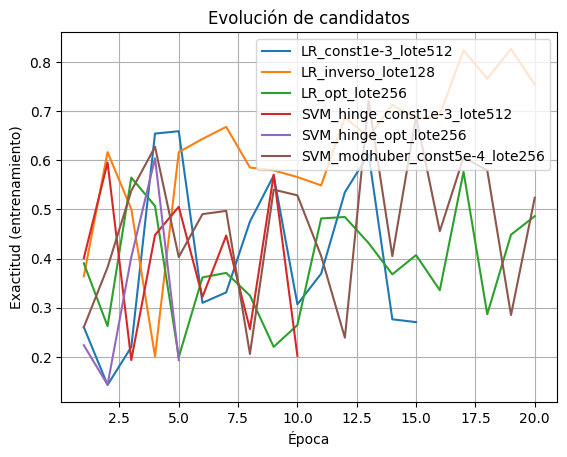

Guardado: F:\Tarea2_IA\Tarea2IAParte2\resultados\ejecucion-20251109-233313\cm_LR_inverso_lote128.png


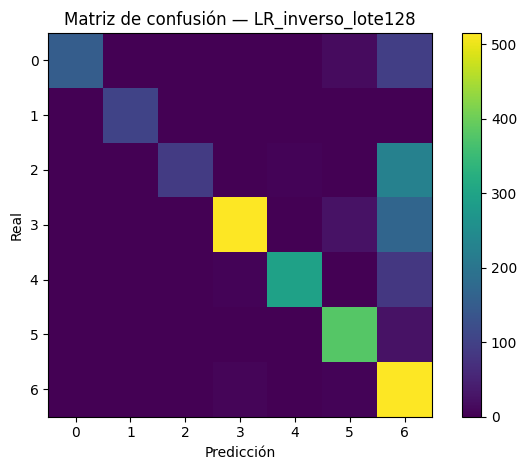

Guardado: F:\Tarea2_IA\Tarea2IAParte2\resultados\ejecucion-20251109-233313\cm_SVM_modhuber_const5e-4_lote256.png


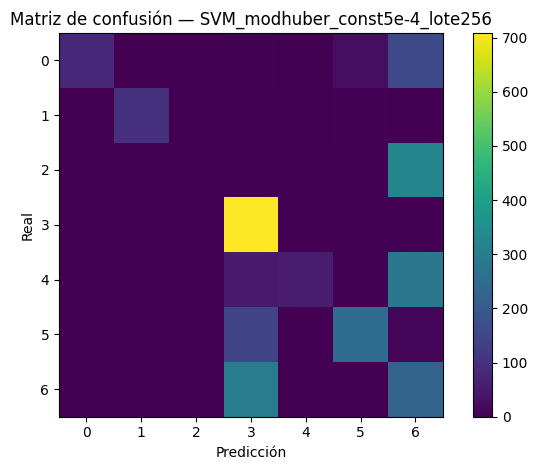

Listo: figuras guardadas en F:\Tarea2_IA\Tarea2IAParte2\resultados\ejecucion-20251109-233313


In [ ]:
# generar figuras automaticamente
# importa funciones de graficos
# detecta la carpeta de ejecucion mas reciente si no existe la especificada
# llama a funciones para generar curvas y matrices de confusion
# imprime confirmacion
from herramientas.graficos import curvas_entrenamiento, matrices_confusion
from pathlib import Path
RUN = Path(run_dir)
if not RUN.exists():
    base = RAIZ / 'resultados'
    cand = sorted([d for d in base.iterdir() if d.is_dir() and d.name.startswith('ejecucion-')])
    RUN = cand[-1] if cand else base
print('usando carpeta para graficas:', RUN)
curvas_entrenamiento(str(RUN))
matrices_confusion(str(RUN))
print('listo: figuras guardadas en', RUN)